# Data ETL and Data Preprocessing

**Load Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("/Users/kevin/Downloads/streaming-bi-template/streaming-bi-template/Data")

def load_csv(filename: str) -> pd.DataFrame:
    fp = DATA_DIR / filename
    if fp.exists():
        print(f"Loaded: {fp}")
        return pd.read_csv(fp)
    raise FileNotFoundError(f"Could not find {filename} in: {DATA_DIR}")

df_movie = load_csv("MoviesOnStreamingPlatforms.csv")
df_tv = load_csv("TVShowsOnStreamingPlatforms.csv")

print(df_movie)
print(df_tv)

Loaded: \Users\kevin\Downloads\streaming-bi-template\streaming-bi-template\Data\MoviesOnStreamingPlatforms.csv
Loaded: \Users\kevin\Downloads\streaming-bi-template\streaming-bi-template\Data\TVShowsOnStreamingPlatforms.csv
        ID                                     Title  Year  Age  \
0        1                              The Irishman  2019  18+   
1        2                                    Dangal  2016   7+   
2        3  David Attenborough: A Life on Our Planet  2020   7+   
3        4         Lagaan: Once Upon a Time in India  2001   7+   
4        5                                      Roma  2018  18+   
...    ...                                       ...   ...  ...   
9510  9511                        Most Wanted Sharks  2020  NaN   
9511  9512             Doc McStuffins: The Doc Is In  2020  NaN   
9512  9513                     Ultimate Viking Sword  2019  NaN   
9513  9514           Hunt for the Abominable Snowman  2011  NaN   
9514  9515       Women of Impact: Changi

**1. Handle Missing Values**

In [2]:
#Checks to see if we have any missing data
def missingness(df: pd.DataFrame) -> pd.Series:
    return df.isna().mean().sort_values(ascending=False)

print("Missingness for Movies:")
display(missingness(df_movie))

print("Missingness for TV Shows:")
display(missingness(df_tv))

Missingness for Movies:


Age                0.438991
Language           0.366684
Genre              0.366264
Country            0.328744
IMDb               0.292486
IMDb_ID            0.286705
Rotten Tomatoes    0.000736
ID                 0.000000
Title              0.000000
Year               0.000000
Netflix            0.000000
Hulu               0.000000
Prime Video        0.000000
Disney+            0.000000
Type               0.000000
dtype: float64

Missingness for TV Shows:


Language           0.619411
Genre              0.588301
IMDb_ID            0.499255
Country            0.497578
Age                0.396237
IMDb               0.162072
ID                 0.000000
Title              0.000000
Year               0.000000
Rotten Tomatoes    0.000000
Netflix            0.000000
Hulu               0.000000
Prime Video        0.000000
Disney+            0.000000
Type               0.000000
dtype: float64

In [3]:
# 2) Common parsing / conversion helpers

def add_rotten_tomatoes_score(df: pd.DataFrame, source_col: str = "Rotten Tomatoes") -> pd.DataFrame:
    """Convert '98/100' -> 98.0 (numeric). Leaves NaN if missing/unparseable."""
    if source_col in df.columns:
        df["RottenTomatoes_Score"] = pd.to_numeric(
            df[source_col].astype(str).str.extract(r"(\d+)")[0],
            errors="coerce"
        )
    return df

def add_age_min(df: pd.DataFrame, source_col: str = "Age") -> pd.DataFrame:
    """Convert '18+' -> 18, '7+' -> 7 (numeric). Leaves NaN if missing/unparseable."""
    if source_col in df.columns:
        df["Age_Min"] = pd.to_numeric(
            df[source_col].astype(str).str.extract(r"(\d+)")[0],
            errors="coerce"
        )
    return df

def standardize_title(df: pd.DataFrame, col: str = "Title") -> pd.DataFrame:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip() # Removes leading and trailing whitespace
    return df

def standardize_type(df: pd.DataFrame, col: str = "Type") -> pd.DataFrame:
    """The datasets encode Type as 0/1. We'll map to readable labels."""
    if col in df.columns:
        # Keep original for reference
        df["Type_raw"] = df[col]
        df[col] = df[col].map({0: "movie", 1: "tv_show"}).fillna(df[col].astype(str))
    return df

def coerce_year(df: pd.DataFrame, col: str = "Year") -> pd.DataFrame:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def coerce_year(df: pd.DataFrame, col: str = "Year") -> pd.DataFrame:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def coerce_platform_flags(df: pd.DataFrame, platform_cols=None) -> pd.DataFrame:
    """Ensure platform columns are numeric 0/1 (safe for grouping & sums)."""
    if platform_cols is None:
        platform_cols = ["Netflix", "Hulu", "Prime Video", "Disney+"]
    for c in platform_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)
    return df

# Apply conversions to BOTH datasets
for _df in (df_movie, df_tv):
    add_rotten_tomatoes_score(_df)
    add_age_min(_df)
    standardize_title(_df)
    standardize_type(_df)
    coerce_year(_df)
    coerce_platform_flags(_df)

df_movie[["Title", "Year", "Age", "Age_Min", "Rotten Tomatoes", "RottenTomatoes_Score", "Type"]].head()

,Title,Year,Age,Age_Min,Rotten Tomatoes,RottenTomatoes_Score,Type
0,The Irishman,2019,18+,18.0,98/100,98.0,movie
1,Dangal,2016,7+,7.0,97/100,97.0,movie
2,David Attenborough: A Life on Our Planet,2020,7+,7.0,95/100,95.0,movie
3,Lagaan: Once Upon a Time in India,2001,7+,7.0,94/100,94.0,movie
4,Roma,2018,18+,18.0,94/100,94.0,movie


In [4]:
# 3) Decide which columns are numeric vs categorical AFTER conversions
def get_num_cat_cols(df: pd.DataFrame):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in df.columns if c not in num_cols]
    return num_cols, cat_cols

num_cols_movie, cat_cols_movie = get_num_cat_cols(df_movie)
num_cols_tv, cat_cols_tv = get_num_cat_cols(df_tv)

print("Movies numeric columns:", num_cols_movie)
print("Movies categorical columns:", cat_cols_movie)

print("\nTV numeric columns:", num_cols_tv)
print("TV categorical columns:", cat_cols_tv)


Movies numeric columns: ['ID', 'Year', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'IMDb', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw']
Movies categorical columns: ['Title', 'Age', 'Rotten Tomatoes', 'Type', 'Genre', 'Country', 'Language', 'IMDb_ID']

TV numeric columns: ['ID', 'Year', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw']
TV categorical columns: ['Title', 'Age', 'Rotten Tomatoes', 'Type', 'Genre', 'Country', 'Language', 'IMDb', 'IMDb_ID']


In [5]:
# 4) Impute missing values (demo pattern)
# NOTE: In real BI pipelines, we usually impute only when it makes business sense.
def impute_basic(df: pd.DataFrame) -> pd.DataFrame:
    num_cols, cat_cols = get_num_cat_cols(df)

    # Numeric: fill with median
    for c in num_cols:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].median())

    # Categorical: fill with mode (or 'Unknown' if no mode)
    for c in cat_cols:
        if df[c].isna().any():
            mode = df[c].mode(dropna=True)
            fill_val = mode.iloc[0] if len(mode) > 0 else "Unknown"
            df[c] = df[c].fillna(fill_val)

    return df

df_movie = impute_basic(df_movie)
df_tv = impute_basic(df_tv)

print("After imputation, missingness (Movies) top 5:")
display(missingness(df_movie).head())

print("\nAfter imputation, missingness (TV) top 5:")
display(missingness(df_tv).head())


After imputation, missingness (Movies) top 5:


ID                      0.0
Title                   0.0
Age_Min                 0.0
RottenTomatoes_Score    0.0
IMDb_ID                 0.0
dtype: float64


After imputation, missingness (TV) top 5:


ID                      0.0
Title                   0.0
Age_Min                 0.0
RottenTomatoes_Score    0.0
IMDb_ID                 0.0
dtype: float64

In [6]:
# 5) Optionally drop rows missing must-have columns (choose intentionally)
# For example, Title and Year are usually required for analysis.
must_have = ["Title", "Year"]  # adjust during the workshop discussion

df_movie_before = len(df_movie)
df_tv_before = len(df_tv)

df_movie = df_movie.dropna(subset=[c for c in must_have if c in df_movie.columns])
df_tv = df_tv.dropna(subset=[c for c in must_have if c in df_tv.columns])

print(f"Movies dropped (must-have): {df_movie_before - len(df_movie)}")
print(f"TV dropped (must-have): {df_tv_before - len(df_tv)}")


Movies dropped (must-have): 0
TV dropped (must-have): 0


In [7]:
# Check: remaining missing values (top 10 columns)
print("Remaining missing values (Movies):")
display(df_movie.isna().sum().sort_values(ascending=False).head(10))

print("\nRemaining missing values (TV):")
display(df_tv.isna().sum().sort_values(ascending=False).head(10))


Remaining missing values (Movies):


ID                      0
Title                   0
Age_Min                 0
RottenTomatoes_Score    0
IMDb_ID                 0
IMDb                    0
Language                0
Country                 0
Genre                   0
Type                    0
dtype: int64


Remaining missing values (TV):


ID                      0
Title                   0
Age_Min                 0
RottenTomatoes_Score    0
IMDb_ID                 0
IMDb                    0
Language                0
Country                 0
Genre                   0
Type                    0
dtype: int64

In [8]:
# Example: validate RottenTomatoes_Score is within 0-100 (Movies)
if "RottenTomatoes_Score" in df_movie.columns:
    bad = ~df_movie["RottenTomatoes_Score"].between(0, 100)
    print("Movies: RottenTomatoes_Score out of range:", int(bad.sum()))

if "RottenTomatoes_Score" in df_tv.columns:
    bad = ~df_tv["RottenTomatoes_Score"].between(0, 100)
    print("TV: RottenTomatoes_Score out of range:", int(bad.sum()))

Movies: RottenTomatoes_Score out of range: 0
TV: RottenTomatoes_Score out of range: 0


# Remove duplicates

In [9]:
# Show duplicate records (entire-row duplicates)
dup_all_movies = df_movie[df_movie.duplicated(keep=False)]
dup_all_tv = df_tv[df_tv.duplicated(keep=False)]

print("Movies: # duplicated rows (entire row):", len(dup_all_movies))
print("TV: # duplicated rows (entire row):", len(dup_all_tv))

display(dup_all_movies.head(10))

Movies: # duplicated rows (entire row): 0
TV: # duplicated rows (entire row): 0


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw


In [10]:
# Deduplicate by a stable key (recommended)
# Here we use (ID, Title) as a simple demo key. Adjust based on business logic.
def dedupe(df: pd.DataFrame, subset_cols):
    before = len(df)
    df2 = df.drop_duplicates(subset=[c for c in subset_cols if c in df.columns], keep="first")
    after = len(df2)
    print(f"Removed {before - after} duplicates using subset={subset_cols}")
    return df2

df_movie = dedupe(df_movie, ["ID", "Title"])
df_tv = dedupe(df_tv, ["ID", "Title"])

Removed 0 duplicates using subset=['ID', 'Title']
Removed 0 duplicates using subset=['ID', 'Title']


# Standardize formats

In [11]:
# 1) Strip whitespace and unify casing (demo)
# Keep Title in original case (more readable), but we can standardize for joins if needed.
# Example: a standardized join key
for _df in (df_movie, df_tv):
    if "Title" in _df.columns:
        _df["Title_key"] = _df["Title"].astype(str).str.strip().str.lower()

df_movie[["Title", "Title_key"]].head()

,Title,Title_key
0,The Irishman,the irishman
1,Dangal,dangal
2,David Attenborough: A Life on Our Planet,david attenborough: a life on our planet
3,Lagaan: Once Upon a Time in India,lagaan: once upon a time in india
4,Roma,roma


In [12]:
display(df_movie.head())

,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18.0,0,the irishman
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7.0,0,dangal
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7.0,0,david attenborough: a life on our planet
3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,movie,"Drama, Musical, Sport","India, United States","Hindi, English",8.1,tt0169102,94.0,7.0,0,lagaan: once upon a time in india
4,5,Roma,2018,18+,94/100,1,0,0,0,movie,Drama,"Mexico, United States","Spanish, Mixtec, English, Japanese, German, Fr...",7.6,tt6155172,94.0,18.0,0,roma


In [13]:
display(df_tv.head())

,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,Breaking Bad,2008,18+,100/100,1,0,0,0,tv_show,"crime television series, drama television seri...",United States,"American English, Spanish language in the Amer...",10.0,tt0903747,100,18.0,1,breaking bad
1,2,Stranger Things,2016,16+,96/100,1,0,0,0,tv_show,"science fiction television program, horror tel...",United States,English,9.0,tt4574334,96,16.0,1,stranger things
2,3,Attack on Titan,2013,18+,95/100,1,1,0,0,tv_show,reality television,United States,English,9.0/10,tt0092400,95,18.0,1,attack on titan
3,4,Better Call Saul,2015,18+,94/100,1,0,0,0,tv_show,"legal drama, crime television series",United States,English,10.0,tt3032476,94,18.0,1,better call saul
4,5,Dark,2017,16+,93/100,1,0,0,0,tv_show,"science fiction television program, drama tele...",Germany,German,10.0,tt5753856,93,16.0,1,dark


In [14]:
# Quick sanity checks
def sanity_checks(df: pd.DataFrame, name: str):
    print(f"--- {name} ---")
    if "Year" in df.columns:
        print("Year min/max:", int(df["Year"].min()), int(df["Year"].max()))
    for c in ["Netflix", "Hulu", "Prime Video", "Disney+"]:
        if c in df.columns:
            print(f"{c} value counts:", df[c].value_counts().to_dict())
    if "RottenTomatoes_Score" in df.columns:
        print("RottenTomatoes_Score describe:")
        display(df["RottenTomatoes_Score"].describe())

sanity_checks(df_movie, "Movies")
sanity_checks(df_tv, "TV Shows")

--- Movies ---
Year min/max: 1914 2021
Netflix value counts: {0: 5820, 1: 3695}
Hulu value counts: {0: 8468, 1: 1047}
Prime Video value counts: {0: 5402, 1: 4113}
Disney+ value counts: {0: 8593, 1: 922}
RottenTomatoes_Score describe:


count    9515.000000
mean       53.543878
std        13.192884
min        10.000000
25%        44.000000
50%        52.000000
75%        62.000000
max        98.000000
Name: RottenTomatoes_Score, dtype: float64

--- TV Shows ---
Year min/max: 1904 2021
Netflix value counts: {0: 3397, 1: 1971}
Hulu value counts: {0: 3747, 1: 1621}
Prime Video value counts: {0: 3537, 1: 1831}
Disney+ value counts: {0: 5017, 1: 351}
RottenTomatoes_Score describe:


count    5368.000000
mean       47.220380
std        19.555753
min        10.000000
25%        36.000000
50%        48.000000
75%        60.000000
max       100.000000
Name: RottenTomatoes_Score, dtype: float64

C:\Users\kevin\AppData\Local\Temp\ipykernel_23792\3133089570.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


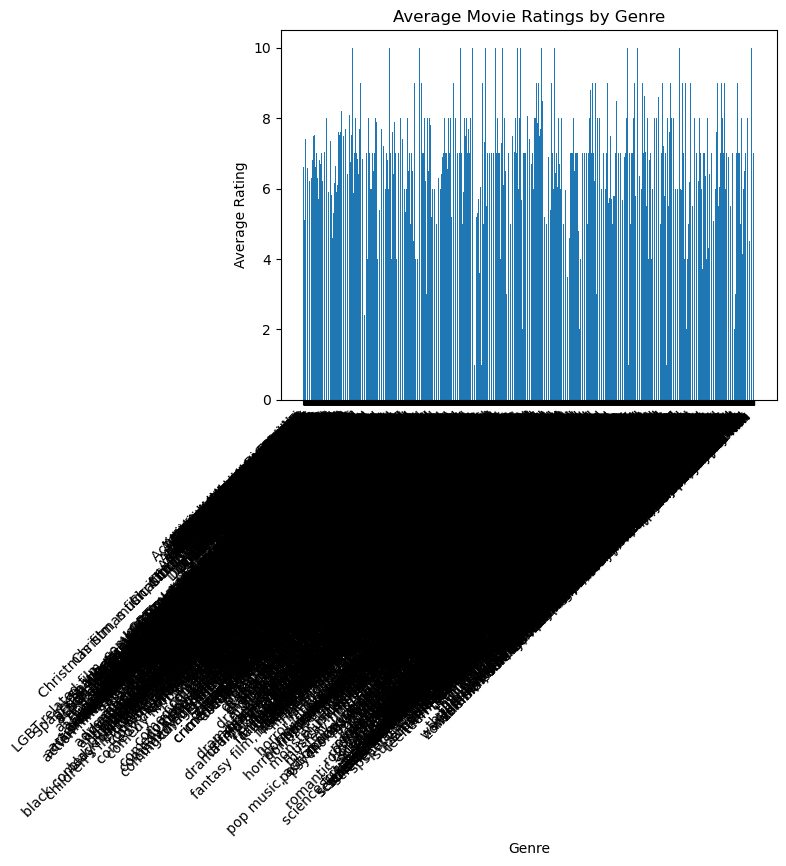

In [19]:
import matplotlib.pyplot as plt

avg_ratings = df_movie.groupby('Genre')['IMDb'].mean()

plt.figure()
plt.bar(avg_ratings.index, avg_ratings.values)
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.title('Average Movie Ratings by Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

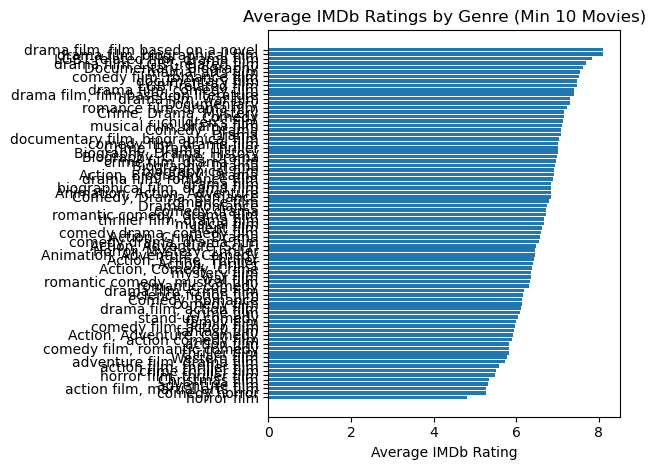

In [20]:

# Keep only genres with enough movies
genre_counts = df_movie['Genre'].value_counts()
top_genres = genre_counts[genre_counts >= 10].index  # adjust threshold

filtered = df_movie[df_movie['Genre'].isin(top_genres)]
avg_ratings = filtered.groupby('Genre')['IMDb'].mean().sort_values()

plt.figure()
plt.barh(avg_ratings.index, avg_ratings.values)
plt.xlabel('Average IMDb Rating')
plt.title('Average IMDb Ratings by Genre (Min 10 Movies)')
plt.tight_layout()
plt.show()

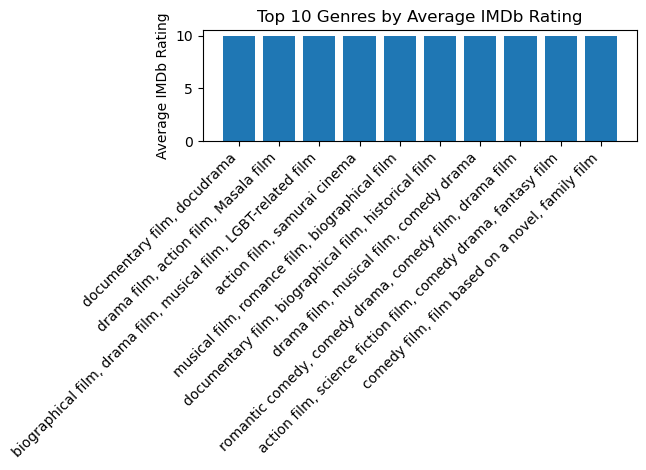

In [21]:
avg_ratings = (
    df_movie.groupby('Genre')['IMDb']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
plt.bar(avg_ratings.index, avg_ratings.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average IMDb Rating')
plt.title('Top 10 Genres by Average IMDb Rating')
plt.tight_layout()
plt.show()